#Feature Construction
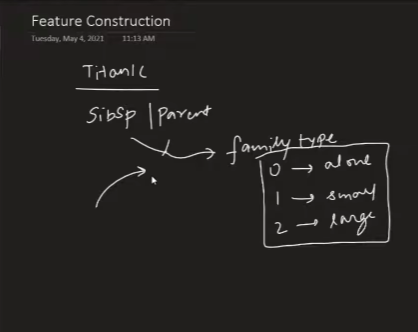

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

import seaborn as sns


In [4]:
df =pd.read_csv("train.csv", usecols=['Age','Pclass','SibSp','Parch','Survived'])

In [11]:
df.head()

,Survived,Pclass,Age,SibSp,Parch
0,0,3,22.0,1,0
1,1,1,38.0,1,0
2,1,3,26.0,0,0
3,1,1,35.0,1,0
4,0,3,35.0,0,0


In [20]:
df['Age'].isnull().sum()

np.int64(0)

In [13]:
df.dropna(inplace = True)

In [7]:
df.head()


,Survived,Pclass,Age,SibSp,Parch
0,0,3,22.0,1,0
1,1,1,38.0,1,0
2,1,3,26.0,0,0
3,1,1,35.0,1,0
4,0,3,35.0,0,0


In [14]:
x=df.iloc[:,0:4]
y=df.iloc[:,-1]

In [15]:
x.head()

,Survived,Pclass,Age,SibSp
0,0,3,22.0,1
1,1,1,38.0,1
2,1,3,26.0,0
3,1,1,35.0,1
4,0,3,35.0,0


In [16]:
y.head()

,Parch
0,0
1,0
2,0
3,0
4,0


In [18]:
np.mean(cross_val_score(LogisticRegression(),x,y,scoring='accuracy',cv=20))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=20.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/mod

np.float64(0.7591269841269843)

#Accuracy without Feature construciton is:
7591269841269843

#now, Feature Construction:


   ### #creating new col name family_size

In [23]:
x['Family_size']= x['SibSp']+ y + 1
#adding 1 here because we have
#to consider that person who is travelling with sibling, spouse, parents or child

In [24]:
x.head()

,Survived,Pclass,Age,SibSp,Family_size
0,0,3,22.0,1,2
1,1,1,38.0,1,2
2,1,3,26.0,0,1
3,1,1,35.0,1,2
4,0,3,35.0,0,1


In [27]:
def myfunc(num):
  if num ==1:
    return 0   #the person is travelling alone
  elif num>1 and num<=4:
    return 1   #the person is travelling with small family
  else:
    return 2   #the person is travelling with large family


In [28]:
myfunc(4)

1

In [29]:
x['family_type']= x['Family_size'].apply(myfunc)

In [30]:
x.head()

,Survived,Pclass,Age,SibSp,Family_size,family_type
0,0,3,22.0,1,2,1
1,1,1,38.0,1,2,1
2,1,3,26.0,0,1,0
3,1,1,35.0,1,2,1
4,0,3,35.0,0,1,0


In [32]:
x.drop(columns=['SibSp','Family_size'],inplace= True)

In [34]:
x.head()

,Survived,Pclass,Age,family_type
0,0,3,22.0,1
1,1,1,38.0,1
2,1,3,26.0,0
3,1,1,35.0,1
4,0,3,35.0,0


In [52]:
np.mean(cross_val_score(LogisticRegression(max_iter=1000),x,y, scoring='accuracy',cv=20))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=20.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/mod

np.float64(0.7830555555555557)

#after applying `Feature construction` the accuracy score is: 0.7830555555555557

# Feature Splitting:

In [37]:
df= pd.read_csv("train.csv")

In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
df['Name']

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [40]:
df['Title']= df['Name'].str.split(',',expand =True)[1].str.split('.',expand=True)[0]

In [42]:
df[['Title','Name']]

,Title,Name
0,Mr,"Braund, Mr. Owen Harris"
1,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,Miss,"Heikkinen, Miss. Laina"
3,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,Mr,"Allen, Mr. William Henry"
...,...,...
886,Rev,"Montvila, Rev. Juozas"
887,Miss,"Graham, Miss. Margaret Edith"
888,Miss,"Johnston, Miss. Catherine Helen ""Carrie"""
889,Mr,"Behr, Mr. Karl Howell"


In [44]:
df['Name'].str.split(',',expand=True)[1]

,1
0,Mr. Owen Harris
1,Mrs. John Bradley (Florence Briggs Thayer)
2,Miss. Laina
3,Mrs. Jacques Heath (Lily May Peel)
4,Mr. William Henry
...,...
886,Rev. Juozas
887,Miss. Margaret Edith
888,"Miss. Catherine Helen ""Carrie"""
889,Mr. Karl Howell


In [49]:
df['Name'].str.split(',',expand =True)[1].str.split('.',expand=True)[0]

,0
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rev
887,Miss
888,Miss
889,Mr


In [56]:
df.groupby('Title')['Survived'].mean().sort_values(ascending=False)

,Survived
Title,
of (Lucy Noel Martha Dyer-Edwards),1.0
(Ada E Hall),1.0
(Amelia Milley),1.0
(Beila),1.0
William Thornton II,1.0
...,...
Ernest Portage,0.0
Ernesti Arvid,0.0
Ernst Adolf,0.0
